# 02 - Data Understanding and Exploratory Data Analysis

## Understanding Energy Use and High-Demand Patterns

### Objective

This notebook explores the cleaned industrial energy dataset to understand how energy consumption and demand vary across assets and over time.

The main goals are:

- understand the structure and coverage of the cleaned dataset
- identify the largest energy-consuming assets and equipment types
- compare energy and demand patterns across assets
- define high-demand periods using asset-specific thresholds
- investigate when high-demand periods occur
- identify patterns that may support the later early-warning model

This exploratory analysis is descriptive. The high-demand thresholds used here are calculated from the full dataset for exploration, while the later machine-learning workflow calculates thresholds using historical training data only to prevent data leakage.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Loading the Cleaned Dataset

I load the cleaned dataset created in Notebook 1 and check that it was saved correctly.

In [2]:
file_path = "../data_processed/manufacturing_energy_clean.csv"

df = pd.read_csv(file_path)

print(df.shape)
df.head()

(1016182, 16)


,AssetId,window_start_utc,DateKeyUtc,TimeKeyUtc,WindowStartLocal,HourLocal,DateLocal,Energy_kWh_15m,Demand_kW,AvgPower_kW_15m,Minutes,SecondsObserved,DataCoveragePct,SecondsReliable,ReliableCoveragePct,asset_type
0,ahu_a,2024-12-31 08:30:00,20241231,83000,2024-12-31 08:30:00,8,2024-12-31,0.003267,0.013069,0.014648,15.0,900.0,100.0,803.0,89.222222,HVAC_AHU
1,ahu_a,2024-12-31 08:45:00,20241231,84500,2024-12-31 08:45:00,8,2024-12-31,0.003604,0.014416,0.014416,15.0,900.0,100.0,900.0,100.000000,HVAC_AHU
2,ahu_a,2024-12-31 09:00:00,20241231,90000,2024-12-31 09:00:00,9,2024-12-31,0.003489,0.013955,0.013955,15.0,900.0,100.0,900.0,100.000000,HVAC_AHU
3,ahu_a,2024-12-31 09:15:00,20241231,91500,2024-12-31 09:15:00,9,2024-12-31,0.003487,0.013948,0.013948,15.0,900.0,100.0,900.0,100.000000,HVAC_AHU
4,ahu_a,2024-12-31 09:30:00,20241231,93000,2024-12-31 09:30:00,9,2024-12-31,0.003733,0.014930,0.014930,15.0,900.0,100.0,900.0,100.000000,HVAC_AHU


## 2. Energy Consumption Across Assets

I first look at how total energy consumption is distributed across the assets and equipment types. This helps identify where most of the measured energy use is concentrated.

In [3]:
energy_by_asset = df.groupby("AssetId")["Energy_kWh_15m"].sum()

energy_by_asset = energy_by_asset.sort_values(ascending=False)

energy_by_asset.head(10)

AssetId
mi_a      1.228614e+06
sb_a      2.754575e+05
p_k       2.074396e+05
ex_b      1.917662e+05
sb_b      1.226538e+05
p_f       1.116056e+05
p_b       8.801093e+04
comp_b    7.637872e+04
comp_a    6.838822e+04
ahu_a     5.511559e+04
Name: Energy_kWh_15m, dtype: float64

### Energy Consumption by Equipment Type

I compare total energy consumption across the different equipment types.

In [4]:
energy_by_type = df.groupby("asset_type")["Energy_kWh_15m"].sum()

energy_by_type = energy_by_type.sort_values(ascending=False)

energy_by_type

asset_type
Electrical_GridImport             1.228614e+06
Press_Main                        5.251486e+05
Electrical_Distribution           3.981810e+05
HVAC_AirExtraction                2.063246e+05
CompressedAir                     1.447669e+05
Press_Drive                       1.270337e+05
Press_IntegratedAutomationCell    1.116056e+05
Utilities                         8.548646e+04
HVAC_AHU                          6.609241e+04
ProcessMixing                     3.598515e+04
Automation_Handling               1.380864e+04
Press_Heating                     9.375438e+03
Automation_Robot                  5.238141e+03
Electrical_PVGeneration           2.888618e+02
HVAC_HeatPump                     8.099704e+01
Name: Energy_kWh_15m, dtype: float64

### Operational Equipment

Some asset types represent electrical infrastructure rather than individual operational equipment. I exclude grid import, electrical distribution and PV generation before comparing the operational assets.

In [5]:
equipment_df = df[
    ~df["asset_type"].isin([
        "Electrical_GridImport",
        "Electrical_Distribution",
        "Electrical_PVGeneration"
    ])
]

energy_by_type_equipment = (
    equipment_df.groupby("asset_type")["Energy_kWh_15m"]
    .sum()
    .sort_values(ascending=False)
)

energy_by_type_equipment

asset_type
Press_Main                        525148.620436
HVAC_AirExtraction                206324.598087
CompressedAir                     144766.940621
Press_Drive                       127033.702301
Press_IntegratedAutomationCell    111605.622295
Utilities                          85486.463680
HVAC_AHU                           66092.405310
ProcessMixing                      35985.146430
Automation_Handling                13808.638959
Press_Heating                       9375.438499
Automation_Robot                    5238.141030
HVAC_HeatPump                         80.997044
Name: Energy_kWh_15m, dtype: float64

### Energy Concentration Across Assets

I now check whether operational energy use is spread evenly across assets or concentrated in a smaller number of large consumers.

In [6]:
energy_by_asset = (
    equipment_df.groupby("AssetId")["Energy_kWh_15m"]
    .sum()
    .sort_values(ascending=False)
)

energy_by_asset.head(10)

AssetId
p_k       207439.559232
ex_b      191766.247549
p_f       111605.622295
p_b        88010.930438
comp_b     76378.717528
comp_a     68388.223093
ahu_a      55115.592692
p_e        54489.772819
p_i        52309.219631
p_l        49369.059961
Name: Energy_kWh_15m, dtype: float64

In [7]:
energy_share = energy_by_asset / energy_by_asset.sum() * 100

print("Top 5 assets:", round(energy_share.head(5).sum(), 1), "%")
print("Top 10 assets:", round(energy_share.head(10).sum(), 1), "%")

Top 5 assets: 50.7 %
Top 10 assets: 71.7 %


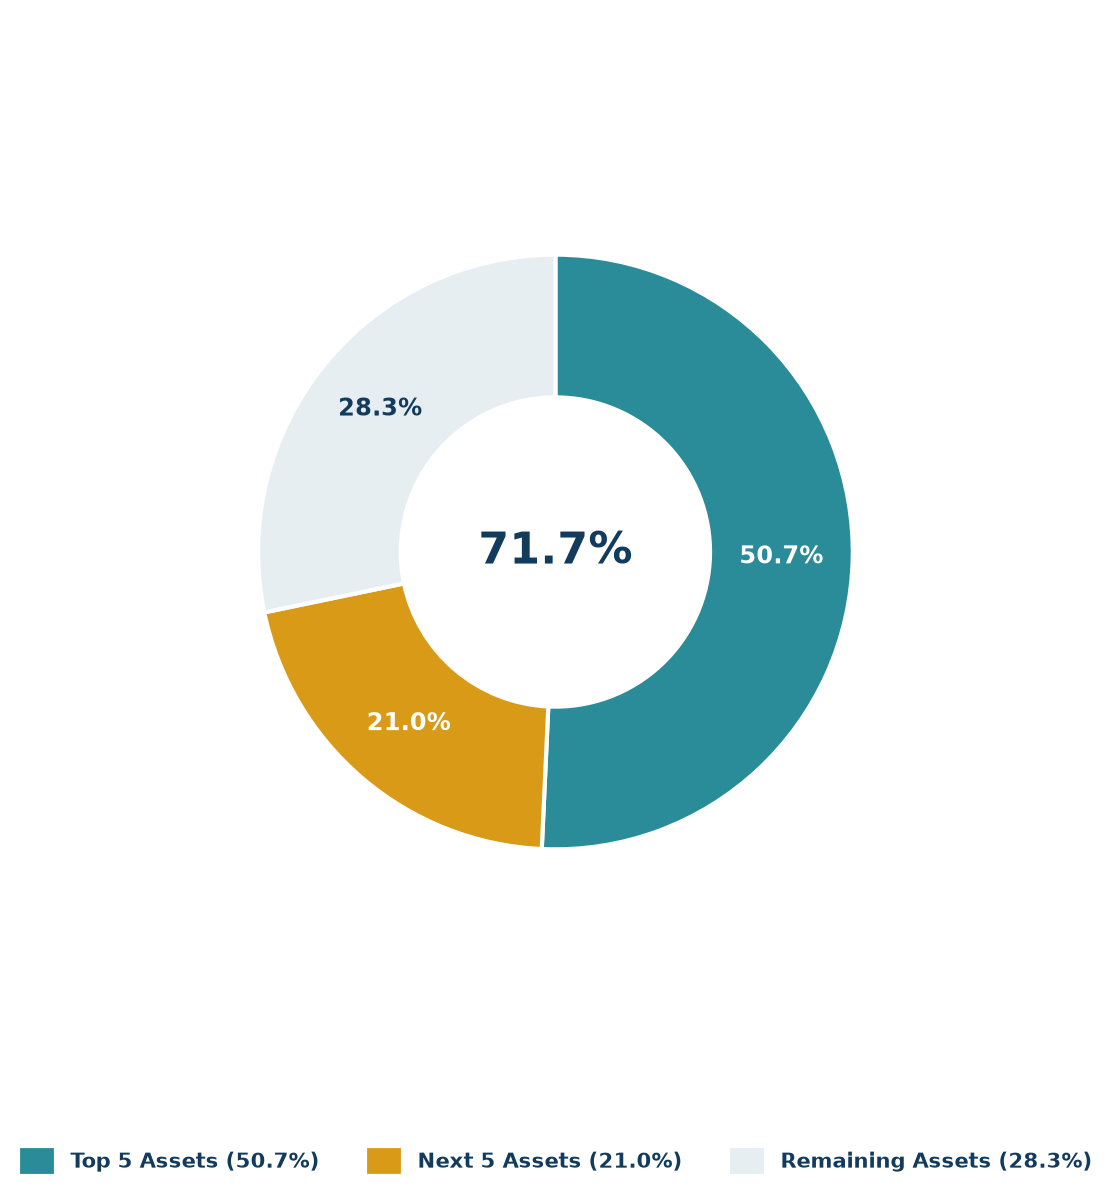

In [8]:
top5_share = energy_share.head(5).sum()
top10_share = energy_share.head(10).sum()

next5_share = top10_share - top5_share
remaining_share = 100 - top10_share

values = [
    top5_share,
    next5_share,
    remaining_share
]

labels = [
    f"Top 5 Assets ({top5_share:.1f}%)",
    f"Next 5 Assets ({next5_share:.1f}%)",
    f"Remaining Assets ({remaining_share:.1f}%)"
]

colors = [
    "#2B8C99",   # teal
    "#D99A18",   # gold
    "#E7EEF2"    # pale blue-grey
]

fig, ax = plt.subplots(figsize=(10, 12))

wedges, texts, autotexts = ax.pie(
    values,
    colors=colors,
    startangle=90,
    counterclock=False,
    autopct="%1.1f%%",
    pctdistance=0.76,
    wedgeprops={
        "width": 0.48,
        "edgecolor": "white",
        "linewidth": 3
    }
)

# Percentage styling
for text in autotexts:
    text.set_fontsize(17)
    text.set_fontweight("bold")

autotexts[0].set_color("white")
autotexts[1].set_color("white")
autotexts[2].set_color("#123B5D")

# Center percentage
ax.text(
    0,
    0,
    f"{top10_share:.1f}%",
    ha="center",
    va="center",
    fontsize=32,
    fontweight="bold",
    color="#123B5D"
)

# Bigger legend below donut
legend = ax.legend(
    wedges,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.03),
    ncol=3,
    frameon=False,

    # Bigger legend text
    fontsize=15,

    # Bigger color boxes
    handlelength=1.8,
    handleheight=1.8,

    # More space between legend items
    columnspacing=2.2,
    handletextpad=0.7
)

# Bold legend text
for text in legend.get_texts():
    text.set_fontweight("bold")
    text.set_color("#123B5D")

ax.axis("equal")

plt.tight_layout()

plt.savefig(
    "../presentation/energy_concentration_donut.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

### Highest Energy-Consuming Assets

The top five operational assets account for 50.7% of measured equipment energy. The following figure shows the ten largest energy consumers.

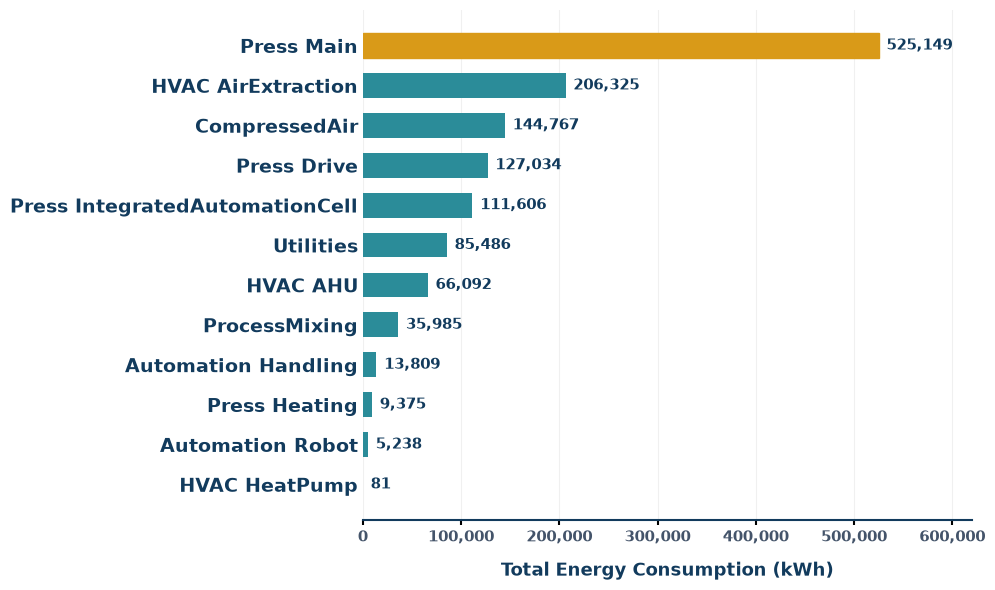

In [9]:
from matplotlib.ticker import FuncFormatter

# Prepare data
energy_type_plot = energy_by_type_equipment.copy()

# Clean category names
clean_labels = (
    energy_type_plot.index
    .str.replace("_", " ", regex=False)
)

# Reverse so largest category appears at the top
values = energy_type_plot.values[::-1]
labels = clean_labels[::-1]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    labels,
    values,
    color="#2B8C99",
    height=0.62
)

# Highlight largest category in gold
bars[-1].set_color("#D99A18")


# --------------------------------------------------
# NUMBERS AT THE END OF EACH BAR
# --------------------------------------------------

max_value = values.max()

for bar, value in zip(bars, values):
    ax.text(
        value + max_value * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold",
        color="#123B5D"
    )


# --------------------------------------------------
# X-AXIS
# --------------------------------------------------

# Thousands separators: 100000 -> 100,000
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)

ax.set_xlabel(
    "Total Energy Consumption (kWh)",
    fontsize=13,
    fontweight="bold",
    color="#123B5D",
    labelpad=12
)

# No unnecessary y-axis title
ax.set_ylabel("")


# --------------------------------------------------
# BIGGER + BOLDER AXIS LABELS
# --------------------------------------------------

ax.tick_params(
    axis="x",
    labelsize=11,
    width=1.5
)

ax.tick_params(
    axis="y",
    labelsize=14,
    length=0
)

# Make tick labels bold
for label in ax.get_xticklabels():
    label.set_fontweight("bold")
    label.set_color("#44546A")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_color("#123B5D")


# --------------------------------------------------
# CLEAN STYLE
# --------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.spines["bottom"].set_linewidth(1.5)
ax.spines["bottom"].set_color("#123B5D")

ax.grid(
    axis="x",
    alpha=0.18,
    linewidth=0.8
)

ax.set_axisbelow(True)

# Extra room for numbers after bars
ax.set_xlim(0, max_value * 1.18)

plt.tight_layout()

plt.savefig(
    "../presentation/energy_by_equipment_type.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

## 3. Comparing Similar Assets

High energy consumption does not automatically mean that an asset is inefficient. Some equipment may be larger or operate for longer periods.

I therefore compare assets belonging to the same equipment type.

In [10]:
asset_comparison = (
    equipment_df.groupby(["asset_type", "AssetId"])["Energy_kWh_15m"]
    .sum()
    .reset_index()
)

asset_comparison.head(10)

,asset_type,AssetId,Energy_kWh_15m
0,Automation_Handling,mh_a,13808.638959
1,Automation_Robot,pr_e,793.732573
2,Automation_Robot,pr_f,2080.774459
3,Automation_Robot,pr_k,2363.633998
4,CompressedAir,comp_a,68388.223093
5,CompressedAir,comp_b,76378.717528
6,HVAC_AHU,ahu_a,55115.592692
7,HVAC_AHU,ahu_b,8626.446064
8,HVAC_AHU,ahu_c,2350.366554
9,HVAC_AirExtraction,ex_a,14558.350539


In [11]:
asset_comparison[
    asset_comparison["asset_type"] == "HVAC_AirExtraction"
]

,asset_type,AssetId,Energy_kWh_15m
9,HVAC_AirExtraction,ex_a,14558.350539
10,HVAC_AirExtraction,ex_b,191766.247549


### Air Extraction Example

The two air extraction assets show a large difference in total energy consumption. I check whether this difference is related to their typical demand, maximum demand or operating time.

In [12]:
air_extraction = equipment_df[
    equipment_df["asset_type"] == "HVAC_AirExtraction"
]

air_summary = air_extraction.groupby("AssetId").agg(
    average_demand=("Demand_kW", "mean"),
    maximum_demand=("Demand_kW", "max"),
    active_periods=("Demand_kW", lambda x: (x > 0).sum())
)

air_summary

,average_demand,maximum_demand,active_periods
AssetId,,,
ex_a,2.751661,14.182442,8578
ex_b,23.116204,34.631680,27754


### Typical Demand Within Equipment Types

To make the comparison more meaningful, I compare the typical active demand of assets within the same equipment type.

In [13]:
active_df = equipment_df[equipment_df["Demand_kW"] > 0]

In [14]:
median_demand = (
    active_df.groupby(["asset_type", "AssetId"])["Demand_kW"]
    .median()
    .reset_index()
)

median_demand

,asset_type,AssetId,Demand_kW
0,Automation_Handling,mh_a,0.390348
1,Automation_Robot,pr_e,0.164200
2,Automation_Robot,pr_f,0.586025
3,Automation_Robot,pr_k,0.819830
4,CompressedAir,comp_a,0.013954
5,CompressedAir,comp_b,19.717677
6,HVAC_AHU,ahu_a,6.133434
7,HVAC_AHU,ahu_b,1.083817
8,HVAC_AHU,ahu_c,0.964817
9,HVAC_AirExtraction,ex_a,9.062789


## 4. Extreme Demand

The project focuses on identifying unusually high demand before it occurs. I first define what extreme demand means for each asset and then examine how these periods are distributed.

### Defining Extreme Demand

The assets operate at very different demand levels, so one fixed threshold would not be suitable for every asset.

I define extreme demand separately for each asset using its 90th percentile. A 15-minute observation is therefore considered extreme when its demand is above the level normally exceeded only 10% of the time.

> **Note:** In this EDA notebook, the thresholds are calculated using the full dataset because they are only used to explore the data. For machine learning, the thresholds are calculated from the training period only to avoid data leakage.

In [15]:
extreme_threshold = df.groupby("AssetId")["Demand_kW"].quantile(0.90)

extreme_threshold.head(10)

AssetId
ahu_a      8.949843
ahu_b      1.484290
ahu_c      1.057922
comp_a    33.131882
comp_b    33.765726
ex_a       9.506471
ex_b      33.604716
hp_a       0.029396
hp_b       0.000430
mh_a       7.881998
Name: Demand_kW, dtype: float64

### Identifying Extreme-Demand Periods

I use each asset's threshold to label every 15-minute observation as normal (`0`) or extreme (`1`).

In [16]:
df["extreme_threshold"] = df["AssetId"].map(extreme_threshold)

df["is_extreme"] = (
    df["Demand_kW"] > df["extreme_threshold"]
).astype(int)

In [17]:
print(df["is_extreme"].value_counts())

print("\nPercentage:")
print(df["is_extreme"].value_counts(normalize=True) * 100)

is_extreme
0    914933
1    101249
Name: count, dtype: int64

Percentage:
is_extreme
0    90.036332
1     9.963668
Name: proportion, dtype: float64


### Severity of Extreme Demand

Because extreme demand is defined using each asset's own 90th percentile, event counts alone are not very informative.

Instead, I compare each asset's typical demand during normal and extreme periods to see which assets show the largest absolute increase.

In [18]:
normal_demand = (
    df[df["is_extreme"] == 0]
    .groupby("AssetId")["Demand_kW"]
    .median()
)

extreme_demand = (
    df[df["is_extreme"] == 1]
    .groupby("AssetId")["Demand_kW"]
    .median()
)

demand_severity = pd.DataFrame({
    "normal_demand": normal_demand,
    "extreme_demand": extreme_demand
})

demand_severity.head()

,normal_demand,extreme_demand
AssetId,,
ahu_a,6.098375,24.325409
ahu_b,1.063531,1.520185
ahu_c,0.000000,1.088750
comp_a,0.009466,36.439680
comp_b,0.019629,36.564034


I use the absolute increase in kW rather than a percentage because some assets normally operate close to zero.

In [19]:
demand_severity["increase_kW"] = (
    demand_severity["extreme_demand"]
    - demand_severity["normal_demand"]
)

demand_severity = demand_severity.sort_values(
    "increase_kW",
    ascending=False
)

demand_severity.head(10)

,normal_demand,extreme_demand,increase_kW
AssetId,,,
mi_a,229.963856,422.171995,192.208139
p_b,0.347248,47.974992,47.627744
sb_a,46.187503,93.275344,47.087841
sb_b,14.380504,60.976285,46.595781
p_f,8.071755,45.389995,37.318240
comp_b,0.019629,36.564034,36.544405
comp_a,0.009466,36.439680,36.430214
p_k,19.989337,50.148390,30.159053
p_l,2.055086,26.077750,24.022664


### Energy Use vs. Peak-Demand Risk

Assets with high annual energy consumption are not necessarily the same assets that show the largest demand increases during extreme periods.

I compare the two rankings to see whether energy-efficiency priorities and peak-demand priorities are different.

In [20]:
equipment_assets = equipment_df["AssetId"].unique()

equipment_severity = demand_severity.loc[
    demand_severity.index.isin(equipment_assets)
]

equipment_severity.head(10)

,normal_demand,extreme_demand,increase_kW
AssetId,,,
p_b,0.347248,47.974992,47.627744
p_f,8.071755,45.389995,37.318240
comp_b,0.019629,36.564034,36.544405
comp_a,0.009466,36.439680,36.430214
p_k,19.989337,50.148390,30.159053
p_l,2.055086,26.077750,24.022664
p_m,0.173862,23.409837,23.235975
p_d,0.174906,22.867877,22.692970
ahu_a,6.098375,24.325409,18.227034


In [21]:
top_energy = energy_by_asset.head(10).index

top_spikes = equipment_severity.head(10).index

common_assets = set(top_energy) & set(top_spikes)

print("Top 10 energy assets:")
print(list(top_energy))

print("\nTop 10 demand-spike assets:")
print(list(top_spikes))

print("\nAssets in both lists:")
print(common_assets)

print("\nNumber in both:", len(common_assets))

Top 10 energy assets:
['p_k', 'ex_b', 'p_f', 'p_b', 'comp_b', 'comp_a', 'ahu_a', 'p_e', 'p_i', 'p_l']

Top 10 demand-spike assets:
['p_b', 'p_f', 'comp_b', 'comp_a', 'p_k', 'p_l', 'p_m', 'p_d', 'ahu_a', 'mix_c']

Assets in both lists:
{'p_f', 'comp_b', 'p_l', 'p_k', 'p_b', 'ahu_a', 'comp_a'}

Number in both: 7


## 5. When Does Extreme Demand Occur?

I now look at when extreme-demand periods occur to see whether demand risk follows the facility's operating schedule.

In [22]:
df["window_start_utc"] = pd.to_datetime(df["window_start_utc"])

In [23]:
df["DateLocal"] = pd.to_datetime(df["DateLocal"])

df["hour"] = df["HourLocal"]
df["day_of_week"] = df["DateLocal"].dt.day_name()
df["month"] = df["DateLocal"].dt.month

### Extreme Demand by Hour

I calculate the percentage of extreme-demand observations at each hour of the day to see when demand risk is highest.

In [24]:
extreme_by_hour = (
    df.groupby("HourLocal")["is_extreme"]
    .mean() * 100
)

extreme_by_hour

HourLocal
0      4.967866
1      6.066176
2      5.718808
3      4.914894
4      5.300846
5      5.964431
6     10.131404
7     13.373120
8     15.390118
9     14.804868
10    15.511481
11    15.685949
12    13.861339
13    14.097166
14    13.185929
15    11.969916
16    11.518028
17     9.440997
18     8.896495
19     8.702423
20     8.374489
21     6.887039
22     7.770909
23     6.912550
Name: is_extreme, dtype: float64

### Weekdays vs. Weekends

I compare weekdays and weekends to see whether extreme-demand risk changes with the facility's operating schedule.

In [25]:
df["day_type"] = df["day_of_week"].apply(
    lambda x: "Weekend" if x in ["Saturday", "Sunday"] else "Weekday"
)

extreme_by_day_type = (
    df.groupby("day_type")["is_extreme"]
    .mean() * 100
)

extreme_by_day_type

day_type
Weekday    12.159723
Weekend     4.345070
Name: is_extreme, dtype: float64

**Finding:** Extreme demand is clearly more common on weekdays than on weekends, suggesting that demand risk is strongly connected to the facility's operating schedule.

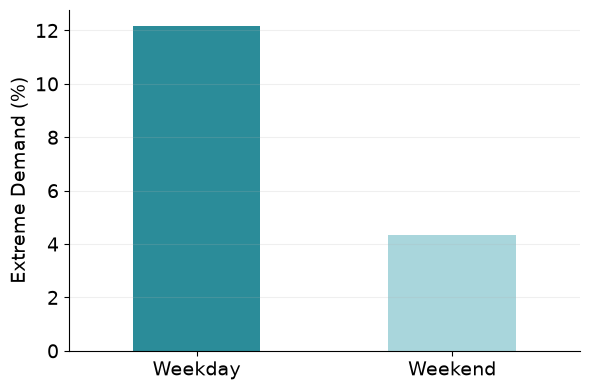

In [26]:
plt.figure(figsize=(6, 4))

extreme_by_day_type.plot(
    kind="bar",
    color=["#2B8C99", "#A9D6DC"]
)


plt.xlabel("")
plt.ylabel("Extreme Demand (%)", fontsize=14)

plt.xticks(rotation=0, fontsize=14)
plt.yticks(fontsize=14)

plt.grid(axis="y", alpha=0.2)

ax = plt.gca()

# Remove only the outer frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Keep x- and y-axis lines
ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)

plt.tight_layout()

plt.savefig(
    "../presentation/weekday_vs_weekend.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

### Weekday High-Risk Window

Since extreme demand is more common on weekdays, I look at the hourly pattern during weekdays to identify the highest-risk operating period.

In [27]:
weekday_df = df[df["day_type"] == "Weekday"]

weekday_hourly = (
    weekday_df.groupby("HourLocal")["is_extreme"]
    .mean() * 100
)

weekday_hourly

HourLocal
0      5.330643
1      6.364955
2      6.384171
3      5.783761
4      6.297836
5      7.146158
6     11.728928
7     16.300439
8     19.077199
9     18.357025
10    19.178849
11    19.520469
12    17.503370
13    17.467980
14    16.308956
15    14.756950
16    13.793216
17    11.389917
18    11.098372
19    10.979365
20    10.600026
21     8.500422
22     9.711159
23     8.552844
Name: is_extreme, dtype: float64

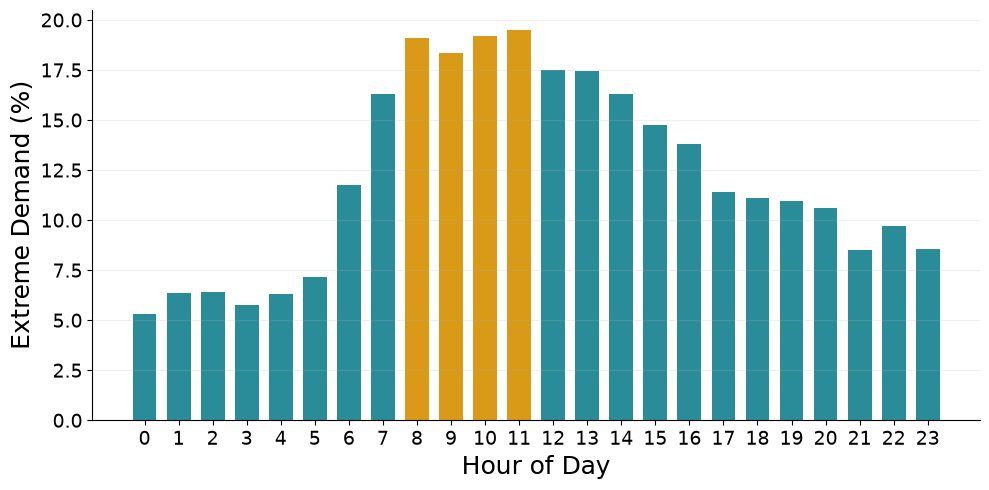

In [28]:
plt.figure(figsize=(10, 5))

plt.bar(
    weekday_hourly.index,
    weekday_hourly.values,
    color="#2B8C99",
    width=0.7
)

colors = [
    "#D99A18" if 8 <= hour <= 11 else "#2B8C99"
    for hour in weekday_hourly.index
]

plt.bar(
    weekday_hourly.index,
    weekday_hourly.values,
    color=colors,
    width=0.7
)


plt.xlabel("Hour of Day", fontsize=18)
plt.ylabel("Extreme Demand (%)", fontsize=18)

plt.xticks(range(24), fontsize=14)
plt.yticks(fontsize=14)

plt.grid(
    axis="y",
    alpha=0.2
)

ax = plt.gca()

# Keep only x- and y-axis lines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../presentation/weekday_hourly_extreme_demand.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

**Finding:** Extreme-demand risk rises strongly during weekday operating hours, from around 6% overnight to approximately 19–20% between 08:00 and 11:00. The highest rate occurs around 11:00, making the morning an important period for demand monitoring.

## 6. What Happens Before Extreme Demand?

The final goal of the project is to predict extreme demand before it occurs. Before building the model, I check whether recent demand already contains useful warning signals.

Because each observation represents 15 minutes, shifting by four rows gives the demand one hour earlier for each asset.

In [29]:
df["demand_1h_ago"] = (
    df.groupby("AssetId")["Demand_kW"]
    .shift(4)
)

In [30]:
df.groupby("is_extreme")["demand_1h_ago"].median()

is_extreme
0    0.537773
1    9.425317
Name: demand_1h_ago, dtype: float64

### Demand One Hour Before

Demand is already higher one hour before extreme periods. Because assets operate at very different demand levels, I also compare the previous demand with each asset's own extreme-demand threshold.

In [31]:
df["demand_1h_ratio"] = (
    df["demand_1h_ago"] / df["extreme_threshold"]
)

In [32]:
df.groupby("is_extreme")["demand_1h_ratio"].median()

is_extreme
0    0.207608
1    1.031434
Name: demand_1h_ratio, dtype: float64

Here, four 15-minute observations are used as an initial one-hour lag for exploratory analysis. Exact one-hour time gaps are checked more carefully in the next time-series notebook.

### Persistence of Extreme Demand

I check how often an extreme-demand observation was already extreme one hour earlier. This helps separate persistent high demand from newly developing extreme-demand periods.

In [33]:
df["was_extreme_1h_ago"] = (
    df["demand_1h_ago"] > df["extreme_threshold"]
).astype(int)

In [34]:
extreme_now = df[df["is_extreme"] == 1]

extreme_now["was_extreme_1h_ago"].value_counts(normalize=True) * 100

was_extreme_1h_ago
1    63.990755
0    36.009245
Name: proportion, dtype: float64

**Finding:** Around 64% of extreme-demand periods were already extreme one hour earlier, while about 36% were not. These new extreme-demand periods are particularly important because they test whether a model can provide a real early warning rather than simply detect demand that is already high.

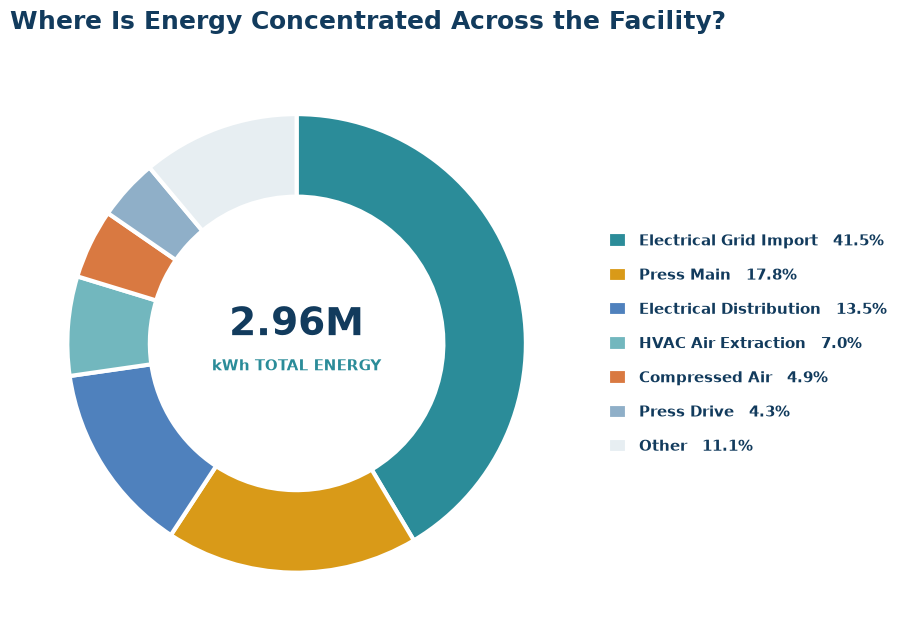

In [35]:

# =========================================================
# PRESENTATION COLORS
# =========================================================

navy = "#123B5D"
teal = "#2B8C99"
gold = "#D99A18"
light_grey = "#E7EEF2"
axis_grey = "#AAB8C2"

# Supporting muted colors
blue = "#4F81BD"
orange = "#D97941"
teal_light = "#72B7BE"
blue_light = "#8FAFC8"


# =========================================================
# DATA FROM THE ORIGINAL EDA RESULT
# =========================================================

categories = [
    "Electrical Grid Import",
    "Press Main",
    "Electrical Distribution",
    "HVAC Air Extraction",
    "Compressed Air",
    "Press Drive",
    "Other"
]

shares = [
    41.5,
    17.8,
    13.5,
    7.0,
    4.9,
    4.3,
    11.1
]


# =========================================================
# COLORS
# =========================================================

colors = [
    teal,          # Grid Import
    gold,          # Press Main
    blue,          # Electrical Distribution
    teal_light,    # HVAC
    orange,        # Compressed Air
    blue_light,    # Press Drive
    light_grey     # Other
]


# =========================================================
# FIGURE
# =========================================================

fig, ax = plt.subplots(figsize=(9.5, 6.5))

fig.patch.set_alpha(0)
ax.set_facecolor("white")


# =========================================================
# DONUT CHART
# =========================================================

wedges, _ = ax.pie(
    shares,
    startangle=90,
    counterclock=False,
    colors=colors,
    wedgeprops={
        "width": 0.36,
        "edgecolor": "white",
        "linewidth": 3
    }
)


# =========================================================
# CENTER TEXT
# =========================================================

ax.text(
    0,
    0.08,
    "2.96M",
    ha="center",
    va="center",
    fontsize=28,
    fontweight="bold",
    color=navy
)

ax.text(
    0,
    -0.10,
    "kWh TOTAL ENERGY",
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold",
    color=teal
)


# =========================================================
# LEGEND
# =========================================================

legend_labels = [
    f"{category}   {share:.1f}%"
    for category, share in zip(categories, shares)
]

legend = ax.legend(
    wedges,
    legend_labels,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=11,
    labelspacing=1.15,
    handlelength=1.2,
    handleheight=1.2
)


for text in legend.get_texts():
    text.set_color(navy)
    text.set_fontweight("bold")


# =========================================================
# TITLE
# =========================================================

ax.set_title(
    "Where Is Energy Concentrated Across the Facility?",
    fontsize=18,
    fontweight="bold",
    color=navy,
    loc="left",
    pad=20
)


# =========================================================
# CLEAN LAYOUT
# =========================================================

ax.set_aspect("equal")

plt.tight_layout()


# =========================================================
# SAVE FOR POWERPOINT
# =========================================================

plt.savefig(
    "../presentation/energy_concentration_backup.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

## 7. From EDA to Machine Learning

The EDA shows that extreme demand is not completely random. It is strongly related to operating time, and recent demand contains information about upcoming high-demand periods.

The next notebooks will use these patterns to create time-based features and build an early-warning model. An important goal will be to identify **new extreme-demand events**, not only periods where demand was already extreme.

## 8. Summary

The exploratory analysis identified several important patterns:

- Energy use is concentrated in a relatively small number of operational assets.
- The top five operational assets account for about 50.7% of measured equipment energy.
- High annual energy use and large demand spikes are not always caused by the same assets.
- Extreme demand is much more common on weekdays than on weekends.
- Weekday mornings, especially around 08:00–11:00, show the highest demand risk.
- Recent demand contains useful information about upcoming extreme-demand periods.
- Around 36% of extreme-demand periods were not extreme one hour earlier, making these events especially important for early-warning prediction.

These findings provide the basis for the time-series analysis and feature engineering in the next notebooks.